# Fine-tuning: one prompt, one reply, no context

Notebook 4 taught the model *language* and notebook 5 rebuilt the same chats as `You` →
`Assistant` pairs. This notebook joins them: it loads the pre-trained checkpoint and keeps
training it, but on pairs instead of a continuous stream.

The name is the design. **No context** means a training sequence is exactly one exchange —
one `You` turn and the `Assistant` reply to it — with no conversation history in front of it.
The model learns "given a message, produce a reply that ends", not "continue this
conversation". Multi-turn context is a different notebook.

```
<|startoftext|>You<|separator|>hey, are you coming?<|endoftext|><|startoftext|>Assistant<|separator|>yeah give me ten minutes<|endoftext|>
```

That whole string is one training sample, padded out to `block_size`.

| Stage | What it produces |
| --- | --- |
| Load | the notebook 5 dataset, and the tokenizer that wrote it |
| Check | that the corpus really does alternate, before anything depends on it |
| Pair | each `You` turn concatenated with its `Assistant` reply |
| Mask | targets where padding is ignored by the loss, not learned |
| Split | train / validation, always on a pair boundary |
| Restore | notebook 4's checkpoint, with its own saved hyperparameters |
| Fine-tune | with evaluation, early stopping, and a best-checkpoint save |
| Talk | a prompt built the same way the training samples were |

**What to expect from the loss.** Every message here was already in the pre-training corpus,
so the model has read all of it. Fine-tuning installs *structure*, not knowledge — a falling
loss is the model learning where a turn begins and ends, not learning anything new about the
world.

In the run stored below, validation fell from **5.27 to 2.92** over three epochs and was
**still falling** when the epochs ran out: early stopping never fired and the checkpoint was
rewritten at every single evaluation. Read that as "three epochs is not enough to exhaust
4,061 pairs", not as the model getting smarter — and as a reason to raise `max_epochs` rather
than to trust this checkpoint as finished.

The thing that visibly changed is at the bottom of the notebook: the replies now **stop on
their own** instead of running to the token limit. That is what teaching `<|endoftext|>` buys,
and it is the one result here that is unambiguous.

## Imports and paths

Both the tokenizer (`minbpe`) and the model (`transformer/model.py`) live outside this
folder, so the path setup has to happen before anything else. `sys.path.append('..')` alone
reaches `transformer` but not `minbpe`, which is the failure this cell exists to avoid.

In [20]:
import sys
from pathlib import Path

# The tutorial's own package (transformer/) sits one level up from Notebooks/.
tutorial_root = Path.cwd().parent
sys.path.insert(0, str(tutorial_root))

try:
    import minbpe
except ModuleNotFoundError:
    for repo_root in (Path.cwd(), *Path.cwd().parents):
        if (repo_root / "minbpe" / "minbpe" / "base.py").exists():
            sys.path.insert(0, str(repo_root / "minbpe"))
            print("using minbpe clone at:", repo_root / "minbpe")
            break
    else:
        raise ModuleNotFoundError(
            "minbpe not found. Install it with "
            "`pip install git+https://github.com/karpathy/minbpe.git`"
        )
else:
    print("using installed minbpe:", Path(minbpe.__file__).parent)

print("tutorial root:", tutorial_root)

using installed minbpe: /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/minbpe/minbpe
tutorial root: /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/TrainYourOwnLLM-Tutorial


In [21]:
import json
import math
import time

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from minbpe import RegexTokenizer
from transformer.model import GPTLanguageModel

torch.manual_seed(3647)

tokenizer = RegexTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    """Number of embedding rows the model needs: one past the largest usable id.

    Not len(vocab) + len(special_tokens). load() rebuilds .vocab with the special tokens
    already folded in, so that expression counts them twice - 1029 on a freshly trained
    tokenizer but 1034 on a reloaded one. Here that is not a subtle problem: the notebook 4
    checkpoint was saved with 1029 embedding rows, so the wrong number makes
    load_state_dict() fail outright on a shape mismatch.
    """
    largest = max(tokenizer.vocab)
    if tokenizer.special_tokens:
        largest = max(largest, *tokenizer.special_tokens.values())
    return largest + 1


vocab_size = get_vocab_size(tokenizer)
print(f"vocab_size = {vocab_size}")

vocab_size = 1029


## Configuration

### Where the numbers come from

Only two of these are free choices. `block_size`, `n_embd`, `n_head`, `n_layer` and
`vocab_size` are **not** set here at all — they are read out of the checkpoint further down,
because a fine-tuning run that disagrees with the model it is loading does not train badly,
it fails to load. Restating them in this cell is exactly how they drift apart.

`batch_size = 32` follows notebook 4's measurement rather than a guess: on Apple MPS, 64 was
91x slower than 32 on this model, not 2x — a memory cliff, not compute. The pre-flight cell
below re-measures on your machine in about thirty seconds.

`learning_rate = 6e-5` is a fifth of the 3e-4 used for pre-training. Fine-tuning starts from
weights that already work; a pre-training learning rate would walk them off the solution
before the format is learned, which shows up as the loss *rising* for the first few hundred
steps and is easy to misread as a bug elsewhere.

In [22]:
# --- Paths ----------------------------------------------------------------
DATASET_PATH = Path("../output/fine_tuning/data/fine_tuning.json")
PRETRAINED_CHECKPOINT = Path("../output/pre_training/run_4/checkpoint.pth")
OUTPUT_CHECKPOINT = Path("../output/fine_tuning/run_1/checkpoint.pth")

# --- The sample format, as notebook 5 wrote it ----------------------------
START_OF_TEXT = "<|startoftext|>"
SEPARATOR = "<|separator|>"
END_OF_TEXT = "<|endoftext|>"
PADDING = "<|padding|>"
USER_ROLE = "You"
ASSISTANT_ROLE = "Assistant"

# torch's cross_entropy ignores this target value by default. Positions marked with it
# contribute nothing to the loss and nothing to the gradient.
IGNORE_INDEX = -100

# --- Training -------------------------------------------------------------
batch_size = 32          # notebook 4 measured 64 as a memory cliff on MPS, not a 2x cost
learning_rate = 6e-5     # a fifth of pre-training's 3e-4; see the note above
grad_clip = 1.0
val_fraction = 0.05

eval_interval = 25       # steps between evaluations
eval_batches = 20        # training batches averaged per evaluation
max_epochs = 3
max_steps = None         # None = run all epochs; set an integer for a quick smoke test
early_stop_patience = 4

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"       # without this branch an Apple machine silently trains on CPU
else:
    device = "cpu"

print(f"device = {device}")

device = mps


### The model's shape comes from the checkpoint

`block_size`, `n_embd`, `n_head`, `n_layer` and `vocab_size` are **not** set in the cell
above, and that is deliberate. Notebook 4 saved them alongside the weights, so they are read
back rather than restated — a fine-tuning notebook that writes `n_embd = 512` next to a
checkpoint holding `n_embd = 384` does not train a slightly wrong model, it fails to load,
and the error points at a tensor rather than at the two numbers that disagree.

It is loaded here, before the data, because `block_size` decides how the pairs are padded.
Loading it once and keeping it also avoids reading a 165 MB file twice.

In [23]:
if not PRETRAINED_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"{PRETRAINED_CHECKPOINT.resolve()} not found - run "
        "4_1_ModelTrainingAllBatches.ipynb first, or point PRETRAINED_CHECKPOINT at "
        "another run"
    )

checkpoint = torch.load(PRETRAINED_CHECKPOINT, map_location=device, weights_only=False)
config = checkpoint["config"]
block_size = config["block_size"]

assert config["vocab_size"] == vocab_size, (
    f"checkpoint was trained with vocab_size={config['vocab_size']} but this tokenizer "
    f"gives {vocab_size} - the embedding table would not fit"
)

print(f"{PRETRAINED_CHECKPOINT.name}: epoch {checkpoint['epoch']}, "
      f"step {checkpoint['step']}, pre-training loss {checkpoint['loss']:.4f}")
for key, value in config.items():
    print(f"  {key:<12} {value}")

checkpoint.pth: epoch 0, step 500, pre-training loss 4.5528
  vocab_size   1029
  block_size   256
  n_embd       512
  n_head       8
  n_layer      4
  dropout      0.2


## The data

### Loading what notebook 5 wrote

A flat JSON list of strings, alternating `You`, `Assistant`, `You`, ... all the way through.
Notebook 5 guarantees that ordering; this notebook is built on it.

In [24]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"{DATASET_PATH.resolve()} not found - run 5_FineTuningDataset.ipynb first"
    )

samples = json.loads(DATASET_PATH.read_text(encoding="utf-8"))

print(f"{len(samples):,} samples ({len(samples) // 2:,} pairs) "
      f"from {DATASET_PATH.resolve()}")
print()
for sample in samples[:2]:
    print(f"  {sample[:96]}{'...' if len(sample) > 96 else ''}")

8,122 samples (4,061 pairs) from /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/TrainYourOwnLLM-Tutorial/output/fine_tuning/data/fine_tuning.json

  <|startoftext|>You<|separator|>yes please, i've been in a reading slump since november
same hone...
  <|startoftext|>Assistant<|separator|>fair. i was thinking we could try "The Salt of Forgotten Ri...


### Check the contract before depending on it

Notebook 5 promises the corpus alternates. This notebook slices it two at a time, so if the
promise were broken every pair after the break would be off by one — a `You` turn matched to
somebody else's reply, all the way to the end.

Nothing about that failure is loud. There is no exception and no shape error; the loss still
falls, just to a worse floor, and the model learns to answer questions it was never asked.
The whole check costs milliseconds, so it runs on every sample rather than a sample of them.

In [25]:
assert samples, "the dataset is empty"
assert all(isinstance(s, str) for s in samples), "every sample must be a string"
assert len(samples) % 2 == 0, f"odd sample count ({len(samples):,}) - they cannot all pair up"

roles = [s[len(START_OF_TEXT):].split(SEPARATOR, 1)[0] for s in samples]
expected = [USER_ROLE, ASSISTANT_ROLE] * (len(samples) // 2)
first_break = next(
    (i for i, (actual, wanted) in enumerate(zip(roles, expected)) if actual != wanted), None
)
assert first_break is None, (
    f"alternation breaks at sample {first_break}: expected {expected[first_break]!r}, "
    f"got {roles[first_break]!r} - re-run 5_FineTuningDataset.ipynb"
)

for sample in samples:
    counts = (sample.count(START_OF_TEXT), sample.count(SEPARATOR), sample.count(END_OF_TEXT))
    assert counts == (1, 1, 1), f"expected one of each marker, got {counts} in {sample[:80]!r}"

# The markers and the padding token have to be single ids, or none of the rest works:
# eos_token_id would match nothing and generation would always run to the token limit.
for marker in (START_OF_TEXT, SEPARATOR, END_OF_TEXT, PADDING):
    assert marker in tokenizer.special_tokens, (
        f"{marker} is not a special token - re-run 2_BytePairEncoding.ipynb"
    )

padding_token = tokenizer.special_tokens[PADDING]
eos_token = tokenizer.special_tokens[END_OF_TEXT]

print(f"{len(samples):,} samples alternate {USER_ROLE} -> {ASSISTANT_ROLE} cleanly "
      f"across all {len(samples) // 2:,} pairs")
print(f"each carries exactly one of each marker\n")
print(f"  {PADDING:<16} id {padding_token}")
print(f"  {END_OF_TEXT:<16} id {eos_token}   <- eos_token_id at generation time")

8,122 samples alternate You -> Assistant cleanly across all 4,061 pairs
each carries exactly one of each marker

  <|padding|>      id 1028
  <|endoftext|>    id 1026   <- eos_token_id at generation time


## Pairing a prompt with its reply

One training sequence is a `You` turn and the `Assistant` turn after it, concatenated. The
model sees the question and the answer as one continuous stream, which is what lets it learn
the transition at the `<|endoftext|><|startoftext|>` boundary in the middle.

**Truncation keeps the end, not the beginning.** A pair longer than `block_size` has to lose
something, and losing the front costs part of the question while losing the back would cost
the `<|endoftext|>` — the single token this entire exercise exists to teach. Only 2 of the
4,061 pairs are affected, but the direction matters more than the count: get it backwards and
those samples teach the model that replies do not end.

In [26]:
def build_pairs(samples: list[str], block_size: int) -> list[list[int]]:
    """Encode each You -> Assistant pair into one sequence of token ids."""
    sequences = []
    for index in range(0, len(samples), 2):
        prompt = tokenizer.encode(samples[index], allowed_special="all")
        reply = tokenizer.encode(samples[index + 1], allowed_special="all")
        sequence = prompt + reply

        # Keep the tail: the reply and its <|endoftext|> survive, the question is clipped.
        if len(sequence) > block_size:
            sequence = sequence[-block_size:]

        sequences.append(sequence)
    return sequences

### Check the pairing

The assertions that matter are about *what ended up next to what*. A pair must open with
`<|startoftext|>` and close with `<|endoftext|>`, and — the one worth stating out loud — it
must contain **two** of each marker, because two whole samples were joined end to end. A pair
carrying one of each means the halves did not concatenate.

Those checks only apply to pairs that were *not* truncated, which is a trap worth naming: an
earlier draft of this cell ran at `block_size=64`, where all four sample pairs overflow, so
every one of them took the truncated branch and the marker assertions never executed at all.
The cell passed while testing nothing. It now runs at the real `block_size`, and asserts that
at least one pair actually reached the untruncated path.

Truncation is then tested deliberately, on a pair built to overflow.

In [27]:
check_pairs = build_pairs(samples[:8], block_size=block_size)
assert len(check_pairs) == 4, f"8 samples should make 4 pairs, got {len(check_pairs)}"

start_id = tokenizer.special_tokens[START_OF_TEXT]
separator_id = tokenizer.special_tokens[SEPARATOR]

untruncated = 0
for index, sequence in enumerate(check_pairs):
    assert sequence[-1] == eos_token, f"pair {index} does not end with <|endoftext|>"
    assert len(sequence) <= block_size, f"pair {index} is longer than block_size"

    if len(sequence) < block_size:                     # i.e. it was not truncated
        untruncated += 1
        assert sequence[0] == start_id, f"pair {index} does not open with <|startoftext|>"
        assert sequence.count(separator_id) == 2, (
            f"pair {index} has {sequence.count(separator_id)} separators, expected 2 "
            "- the two halves did not concatenate"
        )
        assert sequence.count(eos_token) == 2, f"pair {index} is missing an <|endoftext|>"

# Without this, a block_size small enough to truncate everything would skip every assertion
# above and the cell would pass having checked nothing.
assert untruncated >= 1, (
    f"all {len(check_pairs)} sample pairs were truncated at block_size={block_size}, "
    "so the marker checks never ran"
)

# Truncation, tested on purpose: keep the ending, because the reply and its <|endoftext|>
# are the half that carries the training signal.
overflowing = build_pairs([samples[0] * 20, samples[1]], block_size=block_size)[0]
assert len(overflowing) == block_size, "truncation did not clip to block_size"
assert overflowing[-1] == eos_token, "truncation cut the ending instead of the beginning"
assert overflowing[0] != start_id, "the overflowing pair was not actually truncated"

print(f"{len(check_pairs)} pairs from 8 samples, {untruncated} of them untruncated "
      "and carrying two of every marker")
print(f"a {len(samples[0] * 20)}-character pair clipped to {len(overflowing)} tokens, "
      "still ending in <|endoftext|>\n")
print("pair 0, decoded:")
print(f"  {tokenizer.decode(check_pairs[0])[:170]}...")

4 pairs from 8 samples, 4 of them untruncated and carrying two of every marker
a 5260-character pair clipped to 256 tokens, still ending in <|endoftext|>

pair 0, decoded:
  <|startoftext|>You<|separator|>yes please, i've been in a reading slump since november
same honestly, i finished maybe half a book last month
proposal: something with a b...


## Padding, and the loss mask

Sequences are different lengths and a tensor is rectangular, so short pairs get padded out to
`block_size` with `<|padding|>`. That creates a problem the original version of this notebook
described but did not actually solve: **padding must not be learned.** A model scored on
predicting `<|padding|>` will happily learn to emit it, and since padding sits at the end of
every short sample, what it really learns is to end replies with garbage.

The fix is one line and needs no change to the model. `F.cross_entropy` already ignores
target positions equal to `-100` — that is what `ignore_index` defaults to — so the mask is
built into the *targets*, not into the loss function or the model:

```
x  <|startoftext|> You <|separator|> hey <|endoftext|> ... <|padding|> <|padding|>
y  You <|separator|> hey <|endoftext|> ...        -100        -100        -100
```

Reading that column by column: at every position the target is the token that comes next, and
`-100` marks "there is nothing next, do not score this". The last real token
(`<|endoftext|>`) has no successor, so it is masked too.

**What is deliberately *not* masked**: the prompt. The model is scored on predicting the
`You` turn as well as the `Assistant` reply. Masking the prompt so that only the reply carries
gradient is a real and common refinement — it is left out here because it changes what the
notebook teaches, and notebook 5's data is small enough that the extra signal helps.

In [28]:
def pad_and_mask(
    sequences: list[list[int]], block_size: int, padding_token: int
) -> tuple[torch.Tensor, torch.Tensor]:
    """Build (inputs, targets) where padding is masked out of the loss.

    Inputs are right-padded with `padding_token`; targets are the inputs shifted one left,
    with every position that has no real successor set to IGNORE_INDEX.
    """
    inputs = torch.full((len(sequences), block_size), padding_token, dtype=torch.long)
    targets = torch.full((len(sequences), block_size), IGNORE_INDEX, dtype=torch.long)

    for row, ids in enumerate(sequences):
        length = len(ids)
        sequence = torch.tensor(ids, dtype=torch.long)
        inputs[row, :length] = sequence
        # Target t is the token after input t. The last real token has no successor, so
        # positions length-1 onwards keep IGNORE_INDEX.
        targets[row, :length - 1] = sequence[1:]

    return inputs, targets

### Check the mask

Three assertions, and the third is the one that proves the claim above rather than restating
it.

1. **Targets are inputs shifted by one**, everywhere the target is not masked. This is the
   off-by-one that trains happily and produces nonsense.
2. **Every padded position is masked**, and every real position except the last is not.
3. **The loss actually ignores the masked positions.** Computed twice on random logits: once
   the way the model computes it, and once by hand over only the unmasked entries. If
   `-100` were not doing anything, these two numbers would differ.

In [29]:
mask_check = [
    [start_id, 10, 11, separator_id, 12, eos_token],   # 6 real tokens
    [start_id, 20, separator_id, eos_token],           # 4 real tokens
]
x_check, y_check = pad_and_mask(mask_check, block_size=8, padding_token=padding_token)

# 1. targets are inputs shifted left by one, wherever they are not masked
for row, ids in enumerate(mask_check):
    for position in range(len(ids) - 1):
        assert y_check[row, position] == x_check[row, position + 1], (
            f"target misaligned at row {row}, position {position}"
        )

# 2. padding is masked, real tokens (bar the last) are not
for row, ids in enumerate(mask_check):
    assert (y_check[row, len(ids) - 1:] == IGNORE_INDEX).all(), (
        f"row {row} leaves padding unmasked - the model would learn to predict it"
    )
    assert (y_check[row, :len(ids) - 1] != IGNORE_INDEX).all(), (
        f"row {row} masks a real token"
    )
    assert (x_check[row, len(ids):] == padding_token).all(), f"row {row} is padded wrongly"

# 3. the mask changes the loss, which is the entire point of using -100
torch.manual_seed(0)
logits = torch.randn(len(mask_check), 8, vocab_size)
as_model_computes_it = F.cross_entropy(logits.view(-1, vocab_size), y_check.reshape(-1))

keep = y_check.reshape(-1) != IGNORE_INDEX
by_hand = F.cross_entropy(logits.view(-1, vocab_size)[keep], y_check.reshape(-1)[keep])

assert torch.allclose(as_model_computes_it, by_hand), (
    f"cross_entropy is not ignoring the mask: {as_model_computes_it:.6f} vs {by_hand:.6f}"
)
# For contrast: the same loss with padding scored as an ordinary token to predict.
scored_padding = y_check.clone()
scored_padding[scored_padding == IGNORE_INDEX] = padding_token
unmasked = F.cross_entropy(logits.view(-1, vocab_size), scored_padding.reshape(-1))

print(f"x[0] {x_check[0].tolist()}")
print(f"y[0] {y_check[0].tolist()}   <- -100 wherever there is nothing to predict")
print(f"\n{keep.sum().item()} of {keep.numel()} positions carry loss, "
      f"the other {keep.numel() - keep.sum().item()} are masked")
print(f"  masked   {as_model_computes_it:.4f}   over the {keep.sum().item()} real positions")
print(f"  unmasked {unmasked:.4f}   over all {keep.numel()}, padding scored as a token")
print("\nthat the two differ is the mask working; on random logits the *direction* of the")
print("difference means nothing, only that -100 removed those positions from the average")

x[0] [1024, 10, 11, 1025, 12, 1026, 1028, 1028]
y[0] [10, 11, 1025, 12, 1026, -100, -100, -100]   <- -100 wherever there is nothing to predict

8 of 16 positions carry loss, the other 8 are masked
  masked   7.6801   over the 8 real positions
  unmasked 7.5081   over all 16, padding scored as a token

that the two differ is the mask working; on random logits the *direction* of the
difference means nothing, only that -100 removed those positions from the average


### Splitting on a pair boundary

Two differences from notebook 4, both because the data is a different shape.

**The split is random, not contiguous.** Notebook 4 had to split contiguously: its windows
overlapped, so a randomly chosen validation window would share almost all its tokens with a
training window and the validation loss would measure memorisation. Here the samples are
discrete pairs with no overlap at all, so a random split is safe — and much more informative,
because a contiguous 5% would be the tail of one chat (`work_besties`) rather than a sample
of all 23.

**The unit is the pair, not the sample.** Splitting the flat sample list would eventually cut
between a `You` turn and its reply. Pairing first makes that unrepresentable.

Both loaders are built from tensors already on the device — a few MB, so this removes
per-batch transfers, which is also why `num_workers` stays 0.

In [30]:
sequences = build_pairs(samples, block_size=block_size)
inputs, targets = pad_and_mask(sequences, block_size, padding_token)

generator = torch.Generator().manual_seed(3647)
order = torch.randperm(len(sequences), generator=generator)
split_index = int((1 - val_fraction) * len(sequences))
train_index, val_index = order[:split_index], order[split_index:]

train_loader = DataLoader(
    TensorDataset(inputs[train_index].to(device), targets[train_index].to(device)),
    batch_size=batch_size, shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(inputs[val_index].to(device), targets[val_index].to(device)),
    batch_size=batch_size, shuffle=False,
)

lengths = [len(s) for s in sequences]
scored = int((targets != IGNORE_INDEX).sum())

print(f"{len(sequences):,} pairs -> {len(train_index):,} train / {len(val_index):,} validation")
print(f"{len(train_loader)} training batches per epoch, {len(val_loader)} validation batches\n")
print(f"pair length: shortest {min(lengths)}, longest {max(lengths)}, "
      f"median {sorted(lengths)[len(lengths) // 2]} of block_size {block_size}")
print(f"{scored:,} of {targets.numel():,} target positions carry loss "
      f"({scored / targets.numel():.1%}) - the rest is padding")

4,061 pairs -> 3,857 train / 204 validation
121 training batches per epoch, 7 validation batches

pair length: shortest 16, longest 256, median 54 of block_size 256
254,132 of 1,039,616 target positions carry loss (24.4%) - the rest is padding


## The model

Built straight from the config read earlier, so it cannot disagree with the weights about to
go into it.

Two things the original version of this cell got wrong, both fatal before a single step ran:

**It passed `ignore_index=` to `GPTLanguageModel`**, which is not a constructor argument — a
`TypeError` before the model was even built. The masking it was reaching for lives in the
targets instead, above.

**It called `torch.compile(model)` before `load_state_dict`.** Compilation wraps the model so
every `state_dict` key gains an `_orig_mod.` prefix; the pre-trained checkpoint was written
without that prefix, so the load fails on every key at once. Following notebook 4, compilation
is not applied here at all — `save_checkpoint` unwraps it defensively anyway, so you can turn
it on if you benchmark it as a win on your hardware.

In [31]:
model = GPTLanguageModel(**config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])   # raises on any key or shape mismatch
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters, "
      f"restored from {PRETRAINED_CHECKPOINT.name}")

13.79 M parameters, restored from checkpoint.pth


### Did the weights actually load?

`load_state_dict` raises on a mismatched key, but it cannot tell you the weights are
*meaningful* — a freshly initialised model loads a freshly initialised checkpoint without
complaint. The test that distinguishes them is the loss itself.

An untrained model over this vocabulary sits at `ln(1029) = 6.94`, because it has no reason to
prefer any token. A pre-trained one has to be well below that. The assertion is deliberately
loose: it is not checking the model is *good*, only that it is not random — which is the
failure that would otherwise look like "fine-tuning did not work".

In [32]:
random_loss = math.log(vocab_size)

model.eval()
with torch.no_grad():
    x_probe, y_probe = next(iter(val_loader))
    _, loaded_loss = model(x_probe, y_probe)
model.train()

print(f"loss on a validation batch : {loaded_loss:.4f}")
print(f"an untrained model would be: {random_loss:.4f}   (ln of vocab_size {vocab_size})")

assert loaded_loss < random_loss - 0.5, (
    f"loss {loaded_loss:.4f} is too close to random ({random_loss:.4f}) - the checkpoint "
    "weights did not load, or loaded into the wrong model"
)
print("\nthe checkpoint carries real pre-trained weights")

loss on a validation batch : 5.0431
an untrained model would be: 6.9363   (ln of vocab_size 1029)

the checkpoint carries real pre-trained weights


## Fine-tuning

`estimate_loss` averages a bounded number of batches rather than the whole training set. The
original called it over the *entire* train and validation loaders every 20 steps, which on
this dataset is **128 extra forward passes** (121 training batches plus 7 validation) per 20
training steps — more compute spent measuring than training, for a number that twenty batches
estimate just as well.

It also restores whatever mode the model was in instead of assuming `train()`, which matters
because the cell above left it in `eval()`.

`save_checkpoint` creates its parent directory. The original wrote to
`../output/fine_tuning/run_3/`, which does not exist, so the first save raised
`FileNotFoundError` — after a full epoch of training had already happened.

In [33]:
@torch.no_grad()
def estimate_loss(model, loaders: dict, eval_batches: int) -> dict:
    """Average loss over a fixed number of batches from each loader."""
    was_training = model.training
    model.eval()
    try:
        results = {}
        for split, loader in loaders.items():
            losses = []
            for _, (x, y) in zip(range(eval_batches), loader):
                _, loss = model(x, y)
                losses.append(loss.item())
            results[split] = sum(losses) / len(losses)
        return results
    finally:
        model.train(was_training)


def save_checkpoint(model, optimizer, epoch, step, loss, file_path) -> None:
    """Write a checkpoint that a plain GPTLanguageModel can load.

    torch.compile wraps the model and prefixes every state_dict key with '_orig_mod.';
    unwrapping here keeps the checkpoint loadable either way. The directory is created
    rather than assumed.
    """
    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(
        {
            "epoch": epoch,
            "step": step,
            "loss": loss,
            "model_state_dict": getattr(model, "_orig_mod", model).state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": config,
        },
        file_path,
    )

### Pre-flight: what am I committing to?

Time a few real steps and extrapolate before starting. Thirty seconds here is what tells you
whether the run ahead is three minutes or three hours.

The synchronise call is not optional: CUDA and MPS queue work asynchronously, so without it
the timer measures how fast Python submits kernels rather than how long they take.

The model and optimiser are throwaway copies. Timing the real ones would leave the model
several optimiser steps into training before the loop below reports step 0, and the first
number printed would be quietly wrong.

In [34]:
def synchronize(device: str) -> None:
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


def time_steps(model, optimizer, loader, repeats=5):
    batches = [b for _, b in zip(range(repeats + 1), loader)]
    model.train()

    def one_step(x, y):
        _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

    one_step(*batches[0])                       # warm-up, not timed
    synchronize(device)
    start = time.perf_counter()
    for x, y in batches[1:]:
        one_step(x, y)
    synchronize(device)
    return (time.perf_counter() - start) / repeats


timing_model = GPTLanguageModel(**config).to(device)
timing_model.load_state_dict(checkpoint["model_state_dict"])
timing_optimizer = torch.optim.AdamW(timing_model.parameters(), lr=learning_rate)

seconds_per_step = time_steps(timing_model, timing_optimizer, train_loader)
steps_per_epoch = len(train_loader)
total_steps = max_steps if max_steps is not None else steps_per_epoch * max_epochs

del timing_model, timing_optimizer

print(f"{seconds_per_step * 1000:.0f} ms/step at batch_size={batch_size} on {device}")
print(f"{steps_per_epoch} steps/epoch x {max_epochs} epochs = {steps_per_epoch * max_epochs}")
if max_steps is not None:
    print(f"max_steps caps the run at {max_steps} - a smoke test, not a real run")
print(f"\nrunning {total_steps} steps -> about {seconds_per_step * total_steps / 60:.1f} min")

# An evaluation is eval_batches training batches plus a full pass over validation, all
# forward-only - roughly a third the cost of a training step each.
evaluations = max(1, total_steps // eval_interval)
eval_cost = evaluations * (eval_batches + len(val_loader)) * seconds_per_step / 3
print(f"plus ~{evaluations} evaluations, roughly {eval_cost / 60:.1f} min "
      f"({eval_cost / (eval_cost + seconds_per_step * total_steps):.0%} of the total)")

810 ms/step at batch_size=32 on mps
121 steps/epoch x 3 epochs = 363

running 363 steps -> about 4.9 min
plus ~14 evaluations, roughly 1.7 min (26% of the total)


### The loop

Same shape as notebook 4's, with the same two habits worth keeping:

- **The checkpoint is written whenever validation improves**, not once at the end. A run that
  peaks early and drifts afterwards would otherwise save the drifted weights.
- **Early stopping** after `early_stop_patience` evaluations with no improvement, so a run
  that has stopped learning does not keep burning time.

Neither earned its keep in the run below — validation improved at every evaluation, so the
checkpoint was rewritten fifteen times and early stopping never triggered. That is worth
knowing before you read the output as a finished result: this is a run that ended because it
ran out of epochs, not because it ran out of progress.

In [35]:
loaders = {"train": train_loader, "val": val_loader}
history = {"step": [], "train": [], "val": []}

global_step = 0
best_val = float("inf")
best_step = -1
stale_evals = 0
stop = False

model.train()
start_time = time.perf_counter()

for epoch in range(max_epochs):
    if stop:
        break
    for x_batch, y_batch in train_loader:
        if max_steps is not None and global_step >= max_steps:
            stop = True
            break

        if global_step % eval_interval == 0:
            losses = estimate_loss(model, loaders, eval_batches)
            history["step"].append(global_step)
            history["train"].append(losses["train"])
            history["val"].append(losses["val"])

            if losses["val"] < best_val:
                best_val, best_step, stale_evals = losses["val"], global_step, 0
                save_checkpoint(model, optimizer, epoch, global_step, best_val,
                                OUTPUT_CHECKPOINT)
                marker = "  <- saved"
            else:
                stale_evals += 1
                marker = ""

            print(f"epoch {epoch}  step {global_step:>4}/{total_steps}  "
                  f"train {losses['train']:.4f}  val {losses['val']:.4f}{marker}")

            if stale_evals >= early_stop_patience:
                print(f"\nno validation improvement for {stale_evals} evaluations - stopping")
                stop = True
                break

        _, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        global_step += 1

elapsed = time.perf_counter() - start_time
print(f"\n{global_step} steps in {elapsed / 60:.1f} min")
print(f"best validation loss {best_val:.4f} at step {best_step}")
print(f"saved to {OUTPUT_CHECKPOINT.resolve()}")

epoch 0  step    0/363  train 5.2120  val 5.2666  <- saved
epoch 0  step   25/363  train 3.3522  val 3.3573  <- saved
epoch 0  step   50/363  train 3.1370  val 3.1866  <- saved
epoch 0  step   75/363  train 3.0386  val 3.1196  <- saved
epoch 0  step  100/363  train 2.9950  val 3.0797  <- saved
epoch 1  step  125/363  train 2.9411  val 3.0496  <- saved
epoch 1  step  150/363  train 2.8968  val 3.0223  <- saved
epoch 1  step  175/363  train 2.8393  val 3.0051  <- saved
epoch 1  step  200/363  train 2.8682  val 2.9889  <- saved
epoch 1  step  225/363  train 2.8308  val 2.9739  <- saved
epoch 2  step  250/363  train 2.7721  val 2.9649  <- saved
epoch 2  step  275/363  train 2.7570  val 2.9552  <- saved
epoch 2  step  300/363  train 2.7091  val 2.9470  <- saved
epoch 2  step  325/363  train 2.6892  val 2.9382  <- saved
epoch 2  step  350/363  train 2.6637  val 2.9213  <- saved

363 steps in 6.6 min
best validation loss 2.9213 at step 350
saved to /Users/harshpujari/Documents/Work/Aexonic/Pr

### Check the checkpoint can be loaded

A checkpoint you cannot restore is not a checkpoint. Asserting it here, while the fix is
cheap, beats discovering it in the next notebook.

In [36]:
restored = GPTLanguageModel(**config).to(device)
saved = torch.load(OUTPUT_CHECKPOINT, map_location=device, weights_only=False)
restored.load_state_dict(saved["model_state_dict"])

assert saved["config"] == config, "the saved config does not match the model that was trained"
assert saved["step"] == best_step, f"expected the best step ({best_step}), got {saved['step']}"

print(f"restored from {OUTPUT_CHECKPOINT.name}")
print(f"  step {saved['step']}, validation loss {saved['loss']:.4f}")
print(f"  config {saved['config']}")

del restored

restored from checkpoint.pth
  step 350, validation loss 2.9213
  config {'vocab_size': 1029, 'block_size': 256, 'n_embd': 512, 'n_head': 8, 'n_layer': 4, 'dropout': 0.2}


## The loss curve

The usual thing to look for is the moment **validation flattens or turns up while training
keeps falling** — where the model starts memorising instead of learning.

That is not what this run shows, and saying so matters more than the tidy version would.
Validation fell at every evaluation, 5.27 → 2.92, and the two curves stay close the whole way:
2.66 train against 2.92 validation at the end. A gap that small after three passes over the
data means the model is nowhere near memorising it — the run **stopped too early, not too
late**.

Most of the fall happens in the first 25 steps (5.21 → 3.35), which is the model learning the
*format* — where turns start, where they stop. Everything after that is slow grinding on the
contents of the replies, which is the part 176k tokens cannot really support.

The gap between the curves is what to watch as you extend it. While they fall together, more
epochs are still buying something; when the validation line levels off and training keeps
going, `early_stop_patience` will catch it.

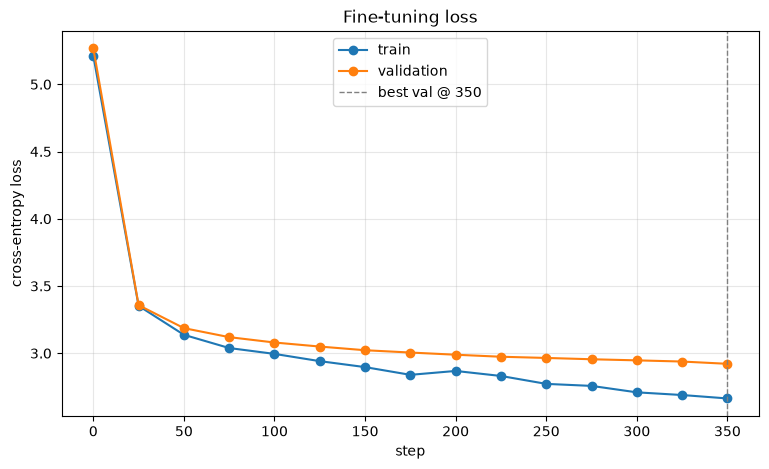

In [37]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib is not installed - `pip install matplotlib` for the chart.\n")
    print(f"{'step':>8}{'train':>10}{'val':>10}")
    for s, t, v in zip(history["step"], history["train"], history["val"]):
        print(f"{s:>8}{t:>10.4f}{v:>10.4f}")
else:
    figure, axis = plt.subplots(figsize=(9, 5))
    axis.plot(history["step"], history["train"], marker="o", label="train")
    axis.plot(history["step"], history["val"], marker="o", label="validation")
    if best_step >= 0:
        axis.axvline(best_step, color="grey", linestyle="--", linewidth=1,
                     label=f"best val @ {best_step}")
    axis.set_xlabel("step")
    axis.set_ylabel("cross-entropy loss")
    axis.set_title("Fine-tuning loss")
    axis.legend()
    axis.grid(alpha=0.3)
    plt.show()

## Talking to it

The prompt has to be built exactly the way the training samples were, which is the whole
reason notebook 5 was so fussy about the format:

```
<|startoftext|>You<|separator|>   your message   <|endoftext|><|startoftext|>Assistant<|separator|>
```

Complete `You` turn, then the `Assistant` turn *opened but not filled in* — the model
continues from the separator, which is how you ask for a reply rather than a continuation.

`model.generate` already does the work the original did by hand. The original ran a
`while True` loop calling `generate(max_new_tokens=1)` one token at a time, re-running the
full forward pass per token, with no iteration cap — so a model that never happened to emit
`<|endoftext|>` would hang the kernel indefinitely. `generate` takes `eos_token_id` and stops
on it, crops to `block_size` itself, and is bounded by `max_new_tokens` either way.

**What the output below actually shows.** Read it in two parts, because they say different
things.

*The part that worked.* All three replies stop on their own, well short of the 60-token limit.
Before fine-tuning this model ran to `max_new_tokens` every time and was cut off mid-sentence;
now it produces `<|endoftext|>` where a turn should end. That is the single thing this
notebook set out to teach, and it is visibly there.

*The part that did not.* The replies are not about anything — `"guys are new would come for
announced it's it"` is the register of the chats without their meaning. At 13.8M parameters
over ~176k distinct tokens, this model is data-starved by roughly three orders of magnitude,
and no amount of fine-tuning fixes that; only more text does.

And one genuine defect worth not hiding: the third reply comes back as
`Assistant<|separator|>Did you eat breakfast.` — the model emitted a **`<|separator|>` inside
its own reply**, opening a turn header where the body should be. It has learned that the
markers exist and roughly what they surround, but not yet that a reply body contains none of
them. `reply_to` decodes the raw continuation rather than stripping stray markers, precisely
so that failure is visible instead of quietly cleaned up.

In [46]:
def reply_to(message: str, max_new_tokens: int = 60, temperature: float = 0.8) -> str:
    """Ask the model for one Assistant reply to one You message."""
    prompt = (
        f"{START_OF_TEXT}{USER_ROLE}{SEPARATOR}{message}{END_OF_TEXT}"
        f"{START_OF_TEXT}{ASSISTANT_ROLE}{SEPARATOR}"
    )
    prompt_ids = tokenizer.encode(prompt, allowed_special="all")
    input_tokens = torch.tensor([prompt_ids], dtype=torch.long, device=device)

    output = model.generate(
        input_tokens=input_tokens,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        eos_token_id=eos_token,
    )

    # Only the continuation, without the prompt that was fed in.
    generated = output[0, len(prompt_ids):].tolist()
    if eos_token in generated:
        generated = generated[:generated.index(eos_token)]
    return tokenizer.decode(generated)


for message in ("hey, are you coming?", "what time works for you", "did you eat"):
    reply = reply_to(message)
    print(f"You:       {message}")
    print(f"Assistant: {reply}\n")

You:       hey, are you coming?
Assistant: this message was deleted

You:       what time works for you
Assistant: bro forever, you are soft on the own, but okay

You:       did you eat
Assistant: checking it for you eat breakfast,.



### Where to go next

- **Train it longer first.** Validation was still falling when the epochs ran out, so
  `max_epochs = 3` is the binding constraint here, not the data. Raise it and let
  `early_stop_patience` decide when to stop; the machinery is already in place and cost about
  6 minutes for three epochs.
- **Mask the prompt if you want a sharper reply model.** Setting the `You` half of each
  sequence to `IGNORE_INDEX` too concentrates every gradient on the reply. It is the single
  highest-value change to this notebook, and it is left out only because the mask above reads
  more clearly with one rule than with two.
- **The stray `<|separator|>` is a data-shape symptom, not a bug to patch at generation time.**
  Filtering markers out of the output would hide it; more training and prompt masking are what
  actually remove it.
- **`Assistant` is 20 different people.** Notebook 5 assigns the role per chat, so the model
  learns the shape of a reply rather than one voice. A single two-party export gives a far
  more coherent result from much less data.
- **More distinct text beats more epochs, eventually.** At ~176k training tokens this model is
  data-starved by roughly three orders of magnitude. Once the validation curve does flatten,
  another export helps and another pass does not.
- **Re-run notebook 5 first if you change the role rule.** `assign_roles` decides the shape of
  every batch here, and nothing in this notebook would notice it had changed.